# Module import

In [147]:
import sys
sys.path.insert(1, "../../module")
import numpy as np      
import snflics
from skimage.transform import resize
from netCDF4 import Dataset                             
from scipy.ndimage import zoom
from matplotlib.patches import Rectangle                
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature                   
import matplotlib.pyplot as plt                         
plt.style.use('default')                               
plt.rcParams['figure.facecolor'] = 'white'
import warnings
warnings.filterwarnings("ignore")
from skimage import measure    
import json
from scipy.ndimage import label
import pandas as pd

# Matplotlib parameterisation

In [109]:
plt.style.use('default')                               
plt.rcParams['figure.facecolor'] = 'white'

# Geodata

In [110]:
geodata = np.load("../../data/geodata/lat_lon_2268_2080.npz")
lons = geodata["lon"][:]
lats = geodata["lat"][:]

# Core data

In [111]:
# file of interest at time t0
file = "../../data/core/202307031815.nc"
data = Dataset(file, mode='r')

# wavelet power maxima's coordinates
x0_lat = data["max_lat"][:]
x0_lon = data["max_lon"][:]

# cloud top temperature and wavelet power arrays
temp = data["tir"][0, :, :]
cores = data["cores"][0, :, :]
binary_cores = (cores != 0).astype(int)

# Plotting cores

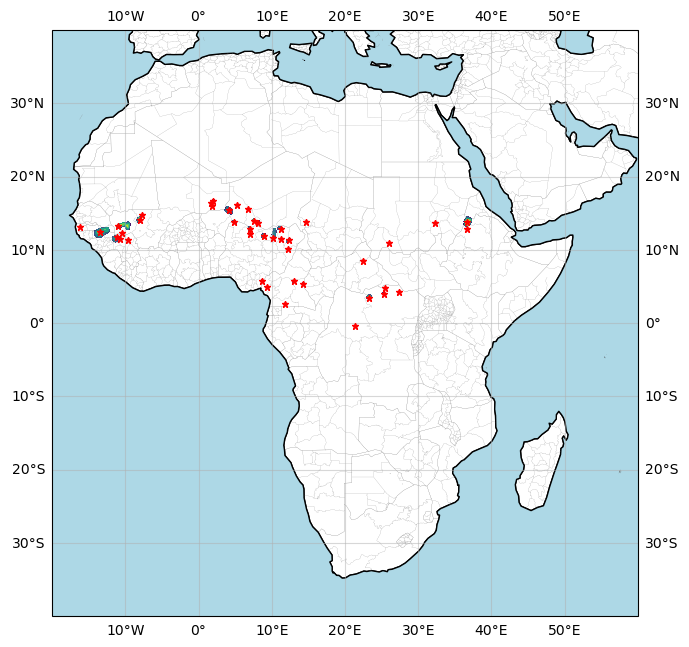

In [112]:
# Define extent
extent = (-20, 60, -40, 40)

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 9), subplot_kw={'projection': ccrs.PlateCarree()})

# Force background to white
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Set map extent
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.1)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Force LAND to be white
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')  # Optional

ax.gridlines(xlocs=np.arange(-20, 60, 10), 
             ylocs=np.arange(-40, 40, 10),
             draw_labels=True, 
             crs=ccrs.PlateCarree(),                
             alpha=0.5
            )

admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
    )

# Add administrative borders
admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)
ax.add_feature(admin_borders, edgecolor='white', linewidth=0.07)

ax.add_feature(admin_borders, edgecolor='black', linewidth=0.06)

contour_core = ax.contourf(lons, lats, cores, levels=[40, 80, 120, 160, 200, 240, 280], transform=ccrs.PlateCarree(), cmap="viridis")

for lt, ln in zip(x0_lat, x0_lon):    
  plt.plot(ln, lt, marker="*", color="red", markersize=5)

plt.tight_layout()
plt.show()

### Finding all the cores (blobs)

- Using the average if we are interested in overall intensity, it is more robust

- less sensitive to noise

- useful for ranking general strenght or impact

In [ ]:
# Label the storm cores
labeled_array, num_cores = label(cores != 0)
core_labels = np.unique(labeled_array[labeled_array != 0])

# Compute storm sizes and mean wavelet power
dict_storm_size = {
    core_label: np.sum(labeled_array == core_label) * 9
    for core_label in core_labels
}

dict_storm_intensity = {
    core_label: np.mean(cores[labeled_array == core_label])
    for core_label in core_labels
}

# Assign storm properties to each labeled storm using x0 coordinates
storm_database = {}
for lat, lon in zip(x0_lat, x0_lon):
    x0_y, x0_x = snflics.to_yx(lat, lon, lats, lons)
    lab = labeled_array[x0_y, x0_x]
    
    # Skip points not associated with a storm or already added
    if lab == 0 or lab in storm_database:
        continue

    storm_database[lab] = {
        "lat": lat,
        "lon": lon,
        "wp": dict_storm_intensity[lab],
        "size": dict_storm_size[lab],
    }

# Convert to pandas DataFrame
storm_df = pd.DataFrame.from_dict(storm_database, orient="index")
storm_df.index.name = "storm_label"
storm_df.reset_index(inplace=True)

In [146]:
storm_df

,storm_label,lat,lon,wp,size
0,1,-0.412913,21.425444,100.849057,477
1,2,2.617949,11.761857,95.181818,198
2,3,3.480636,23.339842,156.071038,3294
3,4,3.962382,25.265448,153.090909,396
4,5,4.309628,27.336216,92.642857,126
5,6,4.852913,25.399288,95.615385,117
6,7,4.907627,9.405815,101.568182,396
7,8,5.392376,14.209880,107.617647,612
8,9,5.744339,13.056723,101.118421,1368
9,10,5.754553,8.674393,94.324324,333


In [144]:
storm_database

{1: {'lat': -0.41291338,
  'lon': 21.425444,
  'wp': 100.84905660377359,
  'size': 477},
 2: {'lat': 2.6179495, 'lon': 11.761857, 'wp': 95.18181818181819, 'size': 198},
 3: {'lat': 3.480636,
  'lon': 23.339842,
  'wp': 156.07103825136613,
  'size': 3294},
 4: {'lat': 3.962382, 'lon': 25.265448, 'wp': 153.0909090909091, 'size': 396},
 5: {'lat': 4.3096285, 'lon': 27.336216, 'wp': 92.64285714285714, 'size': 126},
 6: {'lat': 4.8529134, 'lon': 25.399288, 'wp': 95.61538461538461, 'size': 117},
 7: {'lat': 4.907627, 'lon': 9.405815, 'wp': 101.56818181818181, 'size': 396},
 8: {'lat': 5.392376, 'lon': 14.20988, 'wp': 107.61764705882354, 'size': 612},
 9: {'lat': 5.7443395,
  'lon': 13.056723,
  'wp': 101.11842105263158,
  'size': 1368},
 10: {'lat': 5.754553, 'lon': 8.674393, 'wp': 94.32432432432432, 'size': 333},
 11: {'lat': 8.453429,
  'lon': 22.456797,
  'wp': 100.53488372093024,
  'size': 387},
 12: {'lat': 10.115033,
  'lon': 12.252846,
  'wp': 134.26666666666668,
  'size': 135},
 13: 

In [116]:
dict_storm_size

{'<function label at 0x7fe989ddb420>': 828}

In [117]:
for lat, lon in zip(x0_lat, x0_lon):
    x0_y, x0_x = snflics.to_yx(lat, lon, lats, lons)
    print(x0_y, x0_x)
    print(cores[x0_y, x0_x])

1203 1497
115
1314 1162
105
1344 1558
308
1361 1619
241
1373 1683
99
1393 1622
108
1398 1076
116
1415 1247
130
1428 1206
122
1429 1049
102
1523 1521
115
1586 1172
188
1610 1626
96
1628 1174
172
1645 330
176
1630 384
165
1633 1137
211
1636 348
118
1638 1097
258
1650 1051
234
1666 250
236
1661 984
158
1665 359
138
1668 1917
122
1685 981
168
1684 1133
177
1697 341
256
1698 1915
324
1692 160
133
1699 1799
139
1714 1020
229
1720 905
120
1716 1247
201
1730 445
239
1725 999
336
1750 458
149
1775 879
151
1782 970
106
1795 796
236
1802 918
102
1811 789
179
1818 802
195
